# Crop Calendar Optimization RL Environment

This notebook creates a Gymnasium-compatible RL environment for optimizing planting decisions in Uganda's bimodal rainfall system.

**Environment Design:**

- **Episode**: One growing season (~120 days)
- **State**: Weather conditions, forecasts, crop status, calendar info
- **Actions**: Wait, Plant (short/medium/long cycle varieties)
- **Reward**: Yield-based with risk penalties

**Key Components:**

1. Simplified crop growth model (water balance)
2. Rainfall simulation using trained LSTM World Model
3. Multi-objective reward (yield, risk, efficiency)


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Any, List
from dataclasses import dataclass, field
import warnings
warnings.filterwarnings('ignore')

import torch
import gymnasium as gym
from gymnasium import spaces

DATA_PROCESSED = Path('../data/processed')
MODELS_DIR = Path('../models')

SEED = 42
np.random.seed(SEED)

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'rainfall_features_full.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Region', 'Date']).reset_index(drop=True)

season_dates = pd.read_csv(DATA_PROCESSED / 'season_dates.csv')

print(f"Loaded {len(df):,} rainfall records")
print(f"Regions: {sorted(df['Region'].unique())}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Loaded 67,570 rainfall records
Regions: ['Region1', 'Region2', 'Region3', 'Region4', 'Region5']
Date range: 1983-01-01 to 2019-12-31


In [3]:
import sys
sys.path.insert(0, str(MODELS_DIR.resolve()))
from rainfall_world_model import RainfallWorldModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
world_model = RainfallWorldModel(MODELS_DIR / 'rainfall_lstm_best.pt', device=device)
print(f"World model loaded on {device}")

World model loaded on cpu


## Crop Growth Model

A simplified water balance crop model based on FAO AquaCrop principles:

- Tracks soil water content
- Computes water stress during critical growth stages
- Estimates yield based on cumulative stress


In [4]:
@dataclass
class CropVariety:
    """Crop variety parameters."""
    name: str
    cycle_length: int  # days to maturity
    water_requirement: float  # mm per day average
    potential_yield: float  # tons/ha under optimal conditions
    drought_tolerance: float  # 0-1, higher = more tolerant
    
    # Growth stages (fraction of cycle)
    emergence_frac: float = 0.1
    vegetative_frac: float = 0.3
    flowering_frac: float = 0.2
    grain_filling_frac: float = 0.3
    maturity_frac: float = 0.1
    
    # Stage-specific water sensitivity (higher = more sensitive)
    stage_sensitivity: Dict[str, float] = field(default_factory=lambda: {
        'emergence': 0.8,
        'vegetative': 0.6,
        'flowering': 1.0,  # Most sensitive
        'grain_filling': 0.9,
        'maturity': 0.3
    })


# Define crop varieties 
CROP_VARIETIES = {
    'short': CropVariety(
        name='Early Maturing (Longe 1)',
        cycle_length=90,
        water_requirement=4.5,
        potential_yield=3.5,
        drought_tolerance=0.7
    ),
    'medium': CropVariety(
        name='Medium Maturing (Longe 5)',
        cycle_length=110,
        water_requirement=5.0,
        potential_yield=5.0,
        drought_tolerance=0.5
    ),
    'long': CropVariety(
        name='Late Maturing (Longe 10H)',
        cycle_length=130,
        water_requirement=5.5,
        potential_yield=7.0,
        drought_tolerance=0.3
    )
}

print("Crop varieties defined:")
for key, var in CROP_VARIETIES.items():
    print(f"  {key}: {var.name} ({var.cycle_length} days, {var.potential_yield} t/ha potential)")

Crop varieties defined:
  short: Early Maturing (Longe 1) (90 days, 3.5 t/ha potential)
  medium: Medium Maturing (Longe 5) (110 days, 5.0 t/ha potential)
  long: Late Maturing (Longe 10H) (130 days, 7.0 t/ha potential)


In [5]:
class CropGrowthModel:
    """
    Simplified crop growth model based on water balance.
    
    Simulates:
    - Soil water dynamics (rain input, ET loss)
    - Crop growth stages
    - Water stress accumulation
    - Final yield estimation
    """
    
    def __init__(self, variety: CropVariety, 
                 soil_water_capacity: float = 150.0,  # mm
                 initial_soil_water: float = 50.0):   # mm
        self.variety = variety
        self.soil_water_capacity = soil_water_capacity
        self.initial_soil_water = initial_soil_water
        self.reset()
    
    def reset(self):
        """Reset crop state for new season."""
        self.soil_water = self.initial_soil_water
        self.days_since_planting = 0
        self.is_planted = False
        self.is_mature = False
        self.cumulative_stress = 0.0
        self.stress_by_stage = {stage: 0.0 for stage in 
                                ['emergence', 'vegetative', 'flowering', 'grain_filling', 'maturity']}
        self.daily_stress_history = []
        self.daily_soil_water_history = []
        
    def plant(self):
        """Plant the crop."""
        self.is_planted = True
        self.days_since_planting = 0
        
    def get_current_stage(self) -> str:
        """Get current growth stage based on days since planting."""
        if not self.is_planted:
            return 'not_planted'
        
        frac = self.days_since_planting / self.variety.cycle_length
        
        cum = 0
        for stage, stage_frac in [
            ('emergence', self.variety.emergence_frac),
            ('vegetative', self.variety.vegetative_frac),
            ('flowering', self.variety.flowering_frac),
            ('grain_filling', self.variety.grain_filling_frac),
            ('maturity', self.variety.maturity_frac)
        ]:
            cum += stage_frac
            if frac <= cum:
                return stage
        return 'mature'
    
    def compute_et(self, temperature: float = 25.0) -> float:
        """
        Compute daily evapotranspiration.
        Based on crop coefficient and reference ET.
        """
        if not self.is_planted:
            return 2.0  # Bare soil evaporation
        
        # Crop coefficient varies by growth stage
        stage = self.get_current_stage()
        kc_values = {
            'emergence': 0.4,
            'vegetative': 0.8,
            'flowering': 1.2,
            'grain_filling': 1.0,
            'maturity': 0.6
        }
        kc = kc_values.get(stage, 0.5)
        
        # Reference ET (simplified Hargreaves)
        et0 = 0.0023 * (temperature + 17.8) * 15 * 0.5  # ~4-6 mm/day
        
        return kc * et0
    
    def compute_water_stress(self, et_demand: float) -> float:
        """
        Compute water stress factor (0 = no stress, 1 = max stress).
        Based on soil water availability vs demand.
        """
        if self.soil_water <= 0:
            return 1.0
        
        # Available water fraction
        available_frac = self.soil_water / self.soil_water_capacity
        
        # Stress increases as soil dries below 50% capacity
        critical_frac = 0.5
        if available_frac >= critical_frac:
            stress = 0.0
        else:
            stress = 1 - (available_frac / critical_frac)
        
        # Drought tolerance reduces stress impact
        stress *= (1 - self.variety.drought_tolerance * 0.5)
        
        return min(1.0, max(0.0, stress))
    
    def step(self, rainfall: float, temperature: float = 25.0) -> Dict[str, float]:
        """
        Advance one day.
        
        Args:
            rainfall: Daily rainfall in mm
            temperature: Daily temperature in °C
            
        Returns:
            Dict with daily metrics
        """
        # Update soil water
        self.soil_water += rainfall
        self.soil_water = min(self.soil_water, self.soil_water_capacity)  # Cap at capacity
        
        # Compute ET and water stress
        et = self.compute_et(temperature)
        stress = self.compute_water_stress(et) if self.is_planted else 0.0
        
        # Update soil water (remove ET)
        actual_et = et * (1 - stress * 0.5)  # Reduced ET under stress
        self.soil_water = max(0, self.soil_water - actual_et)
        
        # Accumulate stress if planted
        if self.is_planted and not self.is_mature:
            stage = self.get_current_stage()
            sensitivity = self.variety.stage_sensitivity.get(stage, 0.5)
            weighted_stress = stress * sensitivity
            
            self.cumulative_stress += weighted_stress
            self.stress_by_stage[stage] += weighted_stress
            self.daily_stress_history.append(stress)
            
            self.days_since_planting += 1
            
            # Check for maturity
            if self.days_since_planting >= self.variety.cycle_length:
                self.is_mature = True
        
        self.daily_soil_water_history.append(self.soil_water)
        
        return {
            'rainfall': rainfall,
            'et': actual_et,
            'soil_water': self.soil_water,
            'stress': stress,
            'stage': self.get_current_stage(),
            'days_since_planting': self.days_since_planting
        }
    
    def compute_yield(self) -> float:
        """
        Compute final yield based on cumulative stress.
        Uses a simple yield reduction model.
        """
        if not self.is_planted:
            return 0.0
        
        # Normalize stress by cycle length
        avg_stress = self.cumulative_stress / max(1, self.days_since_planting)
        
        # Yield reduction factor (exponential decay with stress)
        yield_factor = np.exp(-2.0 * avg_stress)
        
        # Penalty for not reaching maturity
        maturity_factor = min(1.0, self.days_since_planting / self.variety.cycle_length)
        
        # Final yield
        final_yield = self.variety.potential_yield * yield_factor * maturity_factor
        
        return final_yield

Final yield: 4.77 t/ha
Potential yield: 5.00 t/ha
Yield achieved: 95.4%


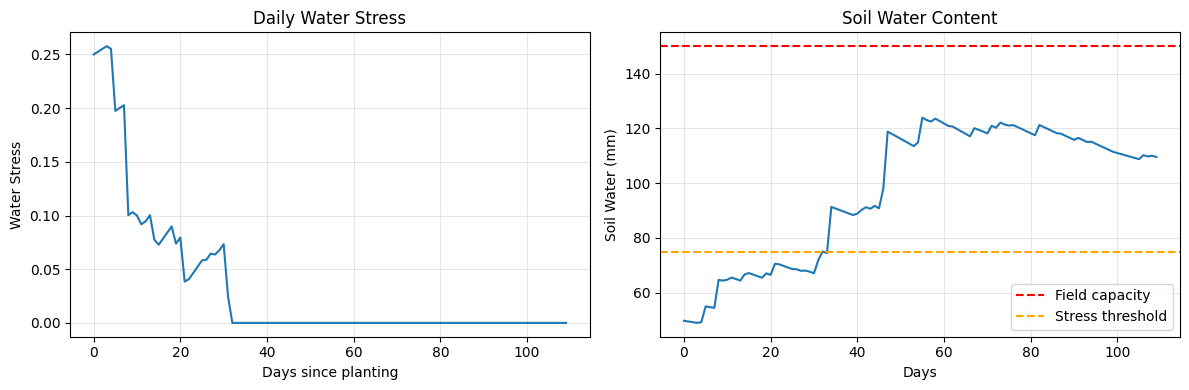

In [6]:
# Test crop growth model with sample rainfall
test_crop = CropGrowthModel(CROP_VARIETIES['medium'])
test_crop.plant()

# Simulate 110 days with synthetic rainfall
np.random.seed(42)
for day in range(110):
    # Synthetic rainfall: rainy season pattern
    if day < 20:  # Early season
        rain = np.random.exponential(3) if np.random.random() < 0.3 else 0
    elif day < 80:  # Peak season
        rain = np.random.exponential(5) if np.random.random() < 0.5 else 0
    else:  # Late season
        rain = np.random.exponential(2) if np.random.random() < 0.2 else 0
    
    test_crop.step(rain)

print(f"Final yield: {test_crop.compute_yield():.2f} t/ha")
print(f"Potential yield: {test_crop.variety.potential_yield:.2f} t/ha")
print(f"Yield achieved: {test_crop.compute_yield()/test_crop.variety.potential_yield*100:.1f}%")

# Plot stress and soil water
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(test_crop.daily_stress_history)
axes[0].set_xlabel('Days since planting')
axes[0].set_ylabel('Water Stress')
axes[0].set_title('Daily Water Stress')
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_crop.daily_soil_water_history)
axes[1].axhline(y=150, color='r', linestyle='--', label='Field capacity')
axes[1].axhline(y=75, color='orange', linestyle='--', label='Stress threshold')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Soil Water (mm)')
axes[1].set_title('Soil Water Content')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Weather Simulator

Uses historical data or the trained World Model to generate weather sequences.


In [7]:
class WeatherSimulator:
    """
    Simulates weather for the RL environment.
    
    Modes:
    - 'historical': Replay actual historical weather
    - 'world_model': Use LSTM predictions
    - 'hybrid': Start with historical, extend with world model
    """
    
    def __init__(self, df: pd.DataFrame, world_model: Optional[RainfallWorldModel] = None,
                mode: str = 'historical'):
        self.df = df
        self.world_model = world_model
        self.mode = mode
        
        self.input_features = [
            'Mean', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos',
            'rainfall_avg_7d', 'rainfall_avg_14d', 'rainfall_avg_30d',
            'rainfall_std_7d', 'rainfall_std_30d',
            'rainy_days_7d', 'rainy_days_30d',
            'clim_mean', 'rainfall_anomaly'
        ]
        
        scaler_params = np.load(MODELS_DIR / 'scaler_params.npy', allow_pickle=True).item()
        self.scaler_mean = scaler_params['mean']
        self.scaler_scale = scaler_params['scale']
        
        self.regions = sorted(df['Region'].unique())
        self.region_to_id = {r: i for i, r in enumerate(self.regions)}
        
        # Precompute climatological means by DOY (for anomaly computation)
        self._compute_climatology()
        
    def _compute_climatology(self):
        """Precompute climatological means by day of year."""
        self.df['DOY'] = self.df['Date'].dt.dayofyear
        self.climatology = self.df.groupby('DOY')['Mean'].mean().to_dict()
        # Fill any missing DOYs with overall mean
        overall_mean = self.df['Mean'].mean()
        for doy in range(1, 367):
            if doy not in self.climatology:
                self.climatology[doy] = overall_mean
        
    def get_historical_data(self, region: str, year: int, 
                        start_doy: int, end_doy: int) -> pd.DataFrame:
        """Get historical weather data for a region/year."""
        mask = (
            (self.df['Region'] == region) &
            (self.df['Year'] == year) &
            (self.df['Date'].dt.dayofyear >= start_doy) &
            (self.df['Date'].dt.dayofyear <= end_doy)
        )
        return self.df[mask].copy()
    
    def get_season_years(self, region: str) -> List[int]:
        """Get available years for a region."""
        return sorted(self.df[self.df['Region'] == region]['Year'].unique())
    
    def normalize_features(self, data: np.ndarray) -> np.ndarray:
        """Normalize features for world model input."""
        return (data - self.scaler_mean) / self.scaler_scale
    
    def _compute_features(self, rainfall_history: np.ndarray, current_doy: int) -> np.ndarray:
        """
        Compute all 14 input features from rainfall history and current DOY.
        
        Features:
        0. Mean - current day rainfall
        1. doy_sin - sin(2π * doy / 365)
        2. doy_cos - cos(2π * doy / 365)
        3. month_sin - sin(2π * month / 12)
        4. month_cos - cos(2π * month / 12)
        5. rainfall_avg_7d - 7-day rolling mean
        6. rainfall_avg_14d - 14-day rolling mean
        7. rainfall_avg_30d - 30-day rolling mean
        8. rainfall_std_7d - 7-day rolling std
        9. rainfall_std_30d - 30-day rolling std
        10. rainy_days_7d - rainy days in last 7 days
        11. rainy_days_30d - rainy days in last 30 days
        12. clim_mean - climatological mean for this DOY
        13. rainfall_anomaly - deviation from climatological mean
        """
        # Current rainfall (last value in history)
        current_rain = rainfall_history[-1] if len(rainfall_history) > 0 else 0.0
        
        # Temporal encoding
        doy_sin = np.sin(2 * np.pi * current_doy / 365)
        doy_cos = np.cos(2 * np.pi * current_doy / 365)
        
        # Approximate month from DOY (1-12)
        month = ((current_doy - 1) // 30) + 1
        month = min(12, max(1, month))
        month_sin = np.sin(2 * np.pi * month / 12)
        month_cos = np.cos(2 * np.pi * month / 12)
        
        # Rolling statistics (use available history)
        last_7 = rainfall_history[-7:] if len(rainfall_history) >= 7 else rainfall_history
        last_14 = rainfall_history[-14:] if len(rainfall_history) >= 14 else rainfall_history
        last_30 = rainfall_history[-30:] if len(rainfall_history) >= 30 else rainfall_history
        
        rainfall_avg_7d = np.mean(last_7) if len(last_7) > 0 else 0.0
        rainfall_avg_14d = np.mean(last_14) if len(last_14) > 0 else 0.0
        rainfall_avg_30d = np.mean(last_30) if len(last_30) > 0 else 0.0
        
        rainfall_std_7d = np.std(last_7) if len(last_7) > 1 else 0.0
        rainfall_std_30d = np.std(last_30) if len(last_30) > 1 else 0.0
        
        # Rainy days (threshold > 1mm)
        rainy_days_7d = np.sum(last_7 > 1) if len(last_7) > 0 else 0
        rainy_days_30d = np.sum(last_30 > 1) if len(last_30) > 0 else 0
        
        # Climatology
        clim_mean = self.climatology.get(current_doy % 365 or 365, 3.0)
        rainfall_anomaly = current_rain - clim_mean
        
        features = np.array([
            current_rain, doy_sin, doy_cos, month_sin, month_cos,
            rainfall_avg_7d, rainfall_avg_14d, rainfall_avg_30d,
            rainfall_std_7d, rainfall_std_30d,
            rainy_days_7d, rainy_days_30d,
            clim_mean, rainfall_anomaly
        ])
        
        return features
    
    def simulate_season(self, region: str, year: int, 
                    start_doy: int = 60, duration: int = 180) -> np.ndarray:
        """
        Simulate a full season of weather.
        
        Returns:
            Array of daily rainfall values (mm)
        """
        if self.mode == 'historical':
            end_doy = min(start_doy + duration, 365)
            data = self.get_historical_data(region, year, start_doy, end_doy)
            rainfall = data['Mean'].values
            
            # Pad if needed
            if len(rainfall) < duration:
                rainfall = np.pad(rainfall, (0, duration - len(rainfall)), 
                                mode='constant', constant_values=0)
            return rainfall[:duration]
        
        elif self.mode == 'world_model':
            # Use world model for simulation
            # Start with historical context (30 days before season start)
            context_data = self.get_historical_data(region, year, 
                                                start_doy - 30, start_doy - 1)
            
            if len(context_data) < 30:
                # Fall back to historical if insufficient context
                return self.simulate_season(region, year, start_doy, duration)
            
            # Initialize rainfall history from context
            rainfall_history = list(context_data['Mean'].values[-30:])
            
            # Extract initial features and normalize
            features = context_data[self.input_features].values[-30:]
            features_norm = self.normalize_features(features)
            
            region_id = self.region_to_id[region]
            
            # Generate rainfall day by day
            generated_rainfall = []
            sequence = features_norm.copy()
            
            for day in range(duration):
                current_doy = start_doy + day
                
                # Predict next day using world model
                if self.world_model is not None:
                    pred = self.world_model.predict(sequence, region_id)
                    # Sample from predicted distribution
                    next_rain = max(0, np.random.normal(pred['mean'][0], pred['std'][0]))
                else:
                    next_rain = np.random.exponential(3)  # Fallback
                
                generated_rainfall.append(next_rain)
                
                # Update rainfall history
                rainfall_history.append(next_rain)
                
                # Compute all features for the new day
                new_features = self._compute_features(
                    np.array(rainfall_history), 
                    current_doy
                )
                
                # Normalize the new features
                new_features_norm = (new_features - self.scaler_mean) / self.scaler_scale
                
                # Shift sequence and add new observation
                sequence = np.roll(sequence, -1, axis=0)
                sequence[-1] = new_features_norm
            
            return np.array(generated_rainfall)
        
        else:
            raise ValueError(f"Unknown mode: {self.mode}")

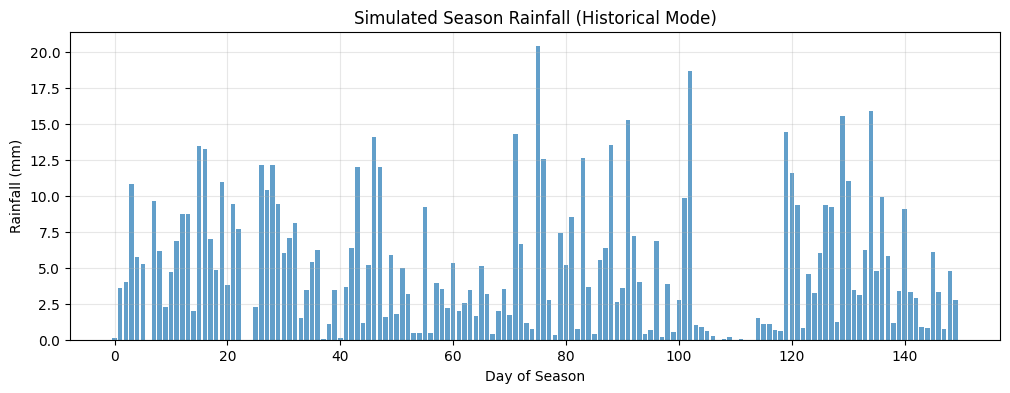

Total rainfall: 754.7 mm
Rainy days: 116


In [8]:
# Test weather simulator
weather_sim = WeatherSimulator(df, world_model=world_model, mode='historical')

# Simulate a season
test_rainfall = weather_sim.simulate_season('Region1', 2015, start_doy=80, duration=150)

plt.figure(figsize=(12, 4))
plt.bar(range(len(test_rainfall)), test_rainfall, alpha=0.7)
plt.xlabel('Day of Season')
plt.ylabel('Rainfall (mm)')
plt.title('Simulated Season Rainfall (Historical Mode)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total rainfall: {test_rainfall.sum():.1f} mm")
print(f"Rainy days: {(test_rainfall > 1).sum()}")

## RL Environment

Gymnasium-compatible environment for crop calendar optimization.


In [9]:
class CropCalendarEnv(gym.Env):
    """
    Gymnasium environment for crop planting calendar optimization.
    
    The agent decides when to plant and which variety to use.
    The goal is to maximize yield while managing weather risk.
    
    Observation Space (continuous):
    - Day of year (sin/cos encoded): 2
    - Days since season start: 1
    - Recent rainfall (7d, 14d, 30d sums): 3
    - Current soil moisture: 1
    - Recent forecast (next 7 days mean): 1
    - Crop status (planted flag, days since planting, growth stage): 3
    - Season progress: 1
    Total: 12 dimensions
    
    Action Space (discrete):
    - 0: Wait (do nothing)
    - 1: Plant short-cycle variety
    - 2: Plant medium-cycle variety
    - 3: Plant long-cycle variety
    
    Reward:
    - At harvest: yield in t/ha (scaled)
    - During season: small penalties for waiting, risk shaping
    """
    
    metadata = {'render_modes': ['human', 'rgb_array']}
    
    def __init__(self, 
                weather_simulator: WeatherSimulator,
                region: str = 'Region1',
                season_start_doy: int = 60,  # March 1
                season_duration: int = 150,  # 5 months
                max_planting_window: int = 60,  # Days to decide on planting
                years: Optional[List[int]] = None,
                render_mode: Optional[str] = None):
        
        super().__init__()
        
        self.weather_sim = weather_simulator
        self.region = region
        self.season_start_doy = season_start_doy
        self.season_duration = season_duration
        self.max_planting_window = max_planting_window
        self.render_mode = render_mode
        
        # Available years for training
        self.years = years or weather_simulator.get_season_years(region)
        
        # Crop varieties
        self.varieties = CROP_VARIETIES
        
        # Define spaces
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32
        )
        
        self.action_space = spaces.Discrete(4)  # wait, plant_short, plant_medium, plant_long
        
        # State variables
        self.current_day = 0
        self.current_year = None
        self.rainfall_data = None
        self.crop = None
        self.episode_reward = 0
        self.history = []
        
    def _get_obs(self) -> np.ndarray:
        """Construct observation vector."""
        doy = self.season_start_doy + self.current_day
        
        # Temporal encoding
        doy_sin = np.sin(2 * np.pi * doy / 365)
        doy_cos = np.cos(2 * np.pi * doy / 365)
        
        # Recent rainfall
        rain_7d = self.rainfall_data[max(0, self.current_day-7):self.current_day].sum()
        rain_14d = self.rainfall_data[max(0, self.current_day-14):self.current_day].sum()
        rain_30d = self.rainfall_data[max(0, self.current_day-30):self.current_day].sum()
        
        # Normalize rainfall
        rain_7d_norm = rain_7d / 50.0  # Rough scaling
        rain_14d_norm = rain_14d / 100.0
        rain_30d_norm = rain_30d / 200.0
        
        # Soil moisture (normalized)
        soil_moisture = self.crop.soil_water / self.crop.soil_water_capacity
        
        # Simple forecast (next 7 days average, if available)
        future_start = self.current_day
        future_end = min(self.current_day + 7, len(self.rainfall_data))
        if future_end > future_start:
            forecast = self.rainfall_data[future_start:future_end].mean() / 10.0
        else:
            forecast = 0.0
        
        # Crop status
        is_planted = float(self.crop.is_planted)
        days_since_planting = self.crop.days_since_planting / 130.0  # Normalize
        
        stage_map = {
            'not_planted': 0.0,
            'emergence': 0.2,
            'vegetative': 0.4,
            'flowering': 0.6,
            'grain_filling': 0.8,
            'maturity': 1.0,
            'mature': 1.0
        }
        growth_stage = stage_map.get(self.crop.get_current_stage(), 0.0)
        
        # Season progress
        season_progress = self.current_day / self.season_duration
        
        obs = np.array([
            doy_sin, doy_cos,
            self.current_day / self.season_duration,  # Days into season
            rain_7d_norm, rain_14d_norm, rain_30d_norm,
            soil_moisture,
            forecast,
            is_planted, days_since_planting, growth_stage,
            season_progress
        ], dtype=np.float32)
        
        return obs
    
    def _get_info(self) -> Dict[str, Any]:
        """Return additional info for debugging."""
        return {
            'day': self.current_day,
            'year': self.current_year,
            'is_planted': self.crop.is_planted,
            'days_since_planting': self.crop.days_since_planting,
            'soil_water': self.crop.soil_water,
            'cumulative_stress': self.crop.cumulative_stress,
            'current_yield': self.crop.compute_yield() if self.crop.is_planted else 0.0
        }
    
    def reset(self, *, seed: Optional[int] = None, 
              options: Optional[Dict] = None) -> Tuple[np.ndarray, Dict]:
        """Reset environment for new episode."""
        super().reset(seed=seed)
        
        # Select a random year
        if options and 'year' in options:
            self.current_year = options['year']
        else:
            self.current_year = self.np_random.choice(self.years)
        
        # Generate rainfall for the season
        self.rainfall_data = self.weather_sim.simulate_season(
            self.region, self.current_year, 
            self.season_start_doy, self.season_duration
        )
        
        # Reset state
        self.current_day = 0
        self.crop = CropGrowthModel(self.varieties['medium'])  # Default variety
        self.episode_reward = 0
        self.history = []
        
        return self._get_obs(), self._get_info()
    
    def step(self, action: int) -> Tuple[np.ndarray, float, bool, bool, Dict]:
        """
        Execute one step in the environment.
        
        Args:
            action: 0=wait, 1=plant_short, 2=plant_medium, 3=plant_long
            
        Returns:
            observation, reward, terminated, truncated, info
        """
        reward = 0.0
        terminated = False
        truncated = False
        
        # Handle planting action
        if not self.crop.is_planted:
            if action == 0:  # Wait
                # Small penalty for waiting if good planting conditions
                if self.crop.soil_water > 50:
                    reward -= 0.01  # Opportunity cost
            elif action in [1, 2, 3]:  # Plant
                variety_map = {1: 'short', 2: 'medium', 3: 'long'}
                variety_key = variety_map[action]
                self.crop = CropGrowthModel(self.varieties[variety_key])
                self.crop.plant()
                
                # Small reward for planting in good conditions
                if self.crop.soil_water > 60:
                    reward += 0.1
                
                # Penalty for planting too late (may not finish)
                days_remaining = self.season_duration - self.current_day
                if days_remaining < self.crop.variety.cycle_length:
                    reward -= 0.5
        
        # Advance weather and crop by one day
        if self.current_day < len(self.rainfall_data):
            daily_rain = self.rainfall_data[self.current_day]
        else:
            daily_rain = 0
        
        step_info = self.crop.step(daily_rain)
        self.current_day += 1
        
        # Record history
        self.history.append({
            'day': self.current_day,
            'rainfall': daily_rain,
            'soil_water': step_info['soil_water'],
            'stress': step_info['stress'],
            'is_planted': self.crop.is_planted,
            'action': action
        })
        
        # Check termination conditions
        # 1. Crop reached maturity
        if self.crop.is_mature:
            final_yield = self.crop.compute_yield()
            reward += final_yield  # Main reward: yield in t/ha
            terminated = True
        
        # 2. Season ended without planting 
        elif self.current_day >= self.max_planting_window and not self.crop.is_planted:
            reward -= 1.0  # Penalty for missing planting window
            terminated = True
        
        # 3. Season ended with immature crop
        elif self.current_day >= self.season_duration:
            if self.crop.is_planted:
                # Partial yield for immature crop
                final_yield = self.crop.compute_yield()
                reward += final_yield * 0.5  # Penalized yield
            terminated = True
        
        self.episode_reward += reward
        
        return self._get_obs(), reward, terminated, truncated, self._get_info()
    
    def render(self):
        """Render the environment state."""
        if self.render_mode == 'human':
            if self.history:
                df_hist = pd.DataFrame(self.history)
                
                fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
                
                # Rainfall
                axes[0].bar(df_hist['day'], df_hist['rainfall'], alpha=0.7, color='blue')
                axes[0].set_ylabel('Rainfall (mm)')
                axes[0].set_title(f'Season {self.current_year} - Episode Summary')
                axes[0].grid(True, alpha=0.3)
                
                # Soil water
                axes[1].fill_between(df_hist['day'], df_hist['soil_water'], alpha=0.5)
                axes[1].axhline(y=75, color='orange', linestyle='--', label='Stress threshold')
                axes[1].set_ylabel('Soil Water (mm)')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)
                
                # Stress
                axes[2].fill_between(df_hist['day'], df_hist['stress'], alpha=0.5, color='red')
                axes[2].set_ylabel('Water Stress')
                axes[2].set_xlabel('Day of Season')
                axes[2].grid(True, alpha=0.3)
                
                # Mark planting day
                planted_days = df_hist[df_hist['is_planted'] & (df_hist['action'] > 0)]
                if not planted_days.empty:
                    plant_day = planted_days['day'].iloc[0]
                    for ax in axes:
                        ax.axvline(x=plant_day, color='green', linestyle='--', 
                                label=f'Planted day {plant_day}')
                
                plt.tight_layout()
                plt.show()
                
                print(f"Episode Reward: {self.episode_reward:.2f}")
                print(f"Final Yield: {self.crop.compute_yield():.2f} t/ha")

## 5. Test Environment


In [10]:
weather_sim = WeatherSimulator(df, world_model=world_model, mode='historical')

env = CropCalendarEnv(
    weather_simulator=weather_sim,
    region='Region1',
    season_start_doy=80,  # Late March
    season_duration=150,
    max_planting_window=60,
    years=list(range(2000, 2015)),  # Training years
    render_mode='human'
)

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Available years: {env.years}")

Observation space: Box(-inf, inf, (12,), float32)
Action space: Discrete(4)
Available years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


In [11]:
obs, info = env.reset(seed=42)
print(f"Initial observation shape: {obs.shape}")
print(f"Initial info: {info}")

# Wait for 10 days, then plant medium variety
total_reward = 0
for step in range(10):
    obs, reward, terminated, truncated, info = env.step(0)  # Wait
    total_reward += reward
    if terminated:
        break

print(f"\nAfter 10 days waiting:")
print(f"  Soil water: {info['soil_water']:.1f} mm")

# Plant medium variety
obs, reward, terminated, truncated, info = env.step(2)  # Plant medium
total_reward += reward
print(f"\nAfter planting:")
print(f"  Reward: {reward:.3f}")
print(f"  Is planted: {info['is_planted']}")

# Run to completion
while not terminated:
    obs, reward, terminated, truncated, info = env.step(0)  # Wait (no action after planting)
    total_reward += reward

print(f"\n{'='*50}")
print(f"Episode Complete!")
print(f"Total Reward: {total_reward:.2f}")
print(f"Final Yield: {info['current_yield']:.2f} t/ha")
print(f"Days to maturity: {info['days_since_planting']}")

Initial observation shape: (12,)
Initial info: {'day': 0, 'year': np.int64(2001), 'is_planted': False, 'days_since_planting': 0, 'soil_water': 50.0, 'cumulative_stress': 0.0, 'current_yield': 0.0}

After 10 days waiting:
  Soil water: 59.5 mm

After planting:
  Reward: 0.000
  Is planted: True

Episode Complete!
Total Reward: 4.87
Final Yield: 4.96 t/ha
Days to maturity: 110


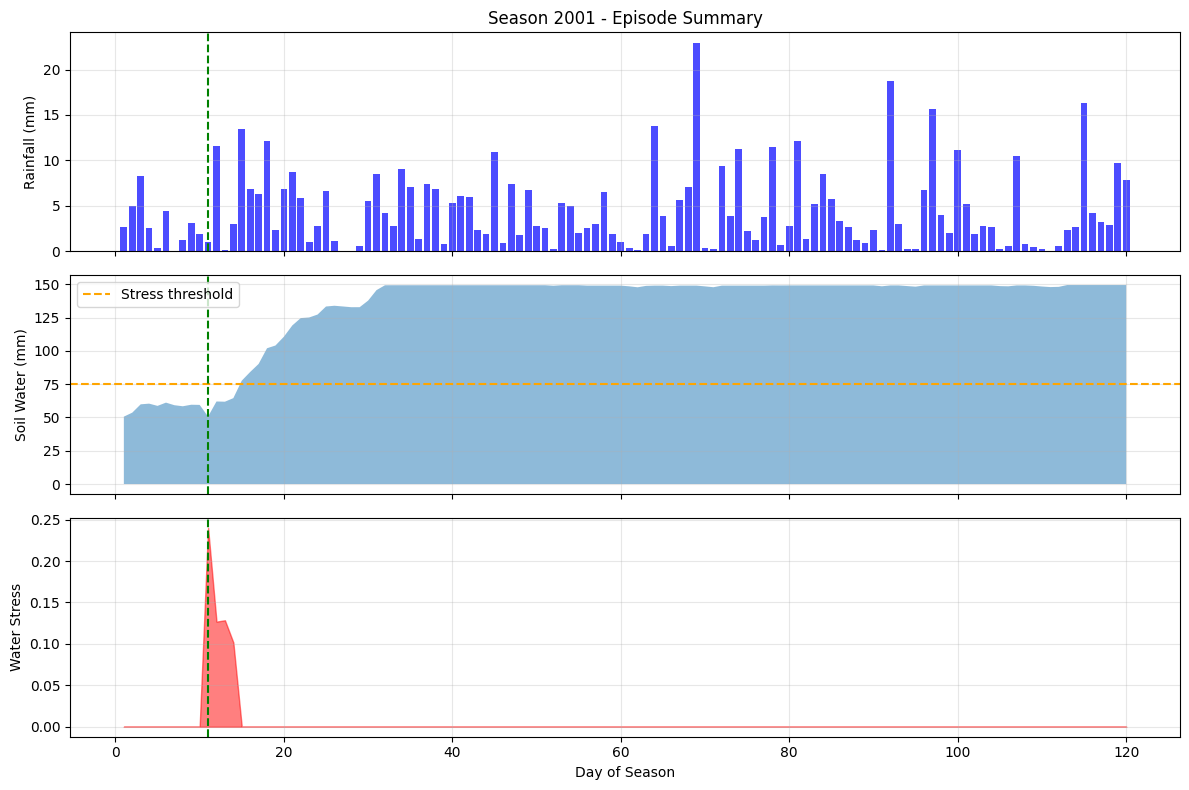

Episode Reward: 4.87
Final Yield: 4.96 t/ha


In [12]:
env.render()

In [13]:
def run_random_agent(env, n_episodes=20):
    """Run random agent and collect statistics."""
    results = []
    
    for ep in range(n_episodes):
        obs, info = env.reset()
        total_reward = 0
        steps = 0
        planted = False
        
        while True:
            # Random action
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            
            total_reward += reward
            steps += 1
            
            if action > 0 and not planted:
                planted = True
                plant_day = steps
            
            if terminated or truncated:
                break
        
        results.append({
            'episode': ep,
            'year': env.current_year,
            'total_reward': total_reward,
            'final_yield': info['current_yield'],
            'steps': steps,
            'planted': planted
        })
    
    return pd.DataFrame(results)

# Run random agent
random_results = run_random_agent(env, n_episodes=50)

print("Random Agent Results:")
print(f"  Mean Reward: {random_results['total_reward'].mean():.2f} ± {random_results['total_reward'].std():.2f}")
print(f"  Mean Yield:  {random_results['final_yield'].mean():.2f} ± {random_results['final_yield'].std():.2f} t/ha")
print(f"  Planted:     {random_results['planted'].mean()*100:.1f}%")

Random Agent Results:
  Mean Reward: 5.07 ± 1.38
  Mean Yield:  5.07 ± 1.38 t/ha
  Planted:     100.0%


In [14]:
# Test heuristic baseline: Plant medium variety when soil is wet enough
def run_heuristic_agent(env, n_episodes=20, soil_threshold=60):
    """Heuristic: Wait until soil moisture > threshold, then plant medium variety."""
    results = []
    
    for ep in range(n_episodes):
        obs, info = env.reset()
        total_reward = 0
        planted = False
        plant_day = None
        
        while True:
            if not planted:
                # Check soil moisture
                soil_moisture = obs[6]  # Normalized soil moisture
                if soil_moisture > (soil_threshold / 150.0):  # Denormalize threshold
                    action = 2  # Plant medium variety
                    planted = True
                    plant_day = env.current_day
                else:
                    action = 0  # Wait
            else:
                action = 0  # Already planted, just wait
            
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            
            if terminated or truncated:
                break
        
        results.append({
            'episode': ep,
            'year': env.current_year,
            'total_reward': total_reward,
            'final_yield': info['current_yield'],
            'plant_day': plant_day,
            'planted': planted
        })
    
    return pd.DataFrame(results)

# Run heuristic agent
heuristic_results = run_heuristic_agent(env, n_episodes=50)

print("\nHeuristic Agent Results (plant when soil > 60mm):")
print(f"  Mean Reward: {heuristic_results['total_reward'].mean():.2f} ± {heuristic_results['total_reward'].std():.2f}")
print(f"  Mean Yield:  {heuristic_results['final_yield'].mean():.2f} ± {heuristic_results['final_yield'].std():.2f} t/ha")
print(f"  Mean Plant Day: {heuristic_results['plant_day'].mean():.1f}")
print(f"  Planted:     {heuristic_results['planted'].mean()*100:.1f}%")


Heuristic Agent Results (plant when soil > 60mm):
  Mean Reward: 4.90 ± 0.04
  Mean Yield:  4.94 ± 0.03 t/ha
  Mean Plant Day: 10.3
  Planted:     100.0%


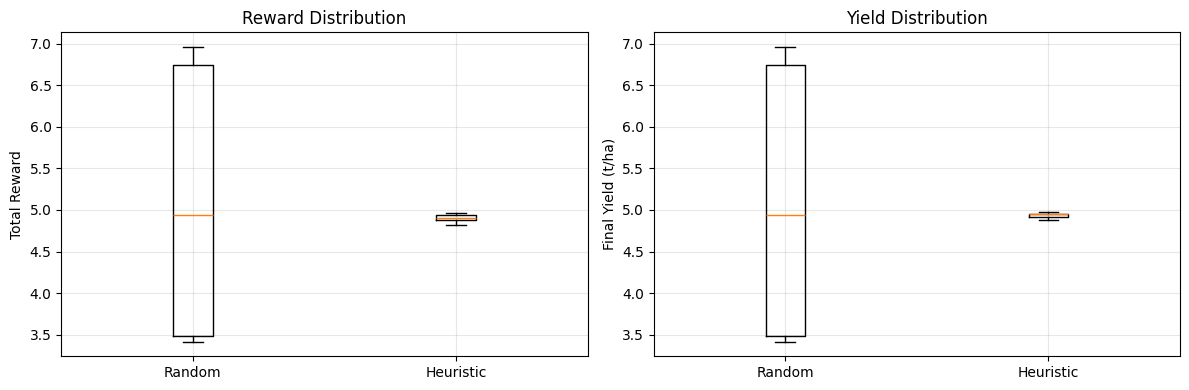

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].boxplot([random_results['total_reward'], heuristic_results['total_reward']],
            labels=['Random', 'Heuristic'])
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Reward Distribution')
axes[0].grid(True, alpha=0.3)


axes[1].boxplot([random_results['final_yield'], heuristic_results['final_yield']],
            labels=['Random', 'Heuristic'])
axes[1].set_ylabel('Final Yield (t/ha)')
axes[1].set_title('Yield Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from gymnasium.envs.registration import register

try:
    register(
        id='CropCalendar-v0',
        entry_point='crop_calendar_env:CropCalendarEnv',
    )
    print("Environment registered as 'CropCalendar-v0'")
except Exception as e:
    print(f"Registration skipped (may already exist): {e}")

Environment registered as 'CropCalendar-v0'
